In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


In [4]:
image_cut = image[56:156, 0:1890]
image_error_cut = image_error[56:156, 0:1890]

Text(0.5, 0, 'wavelength')

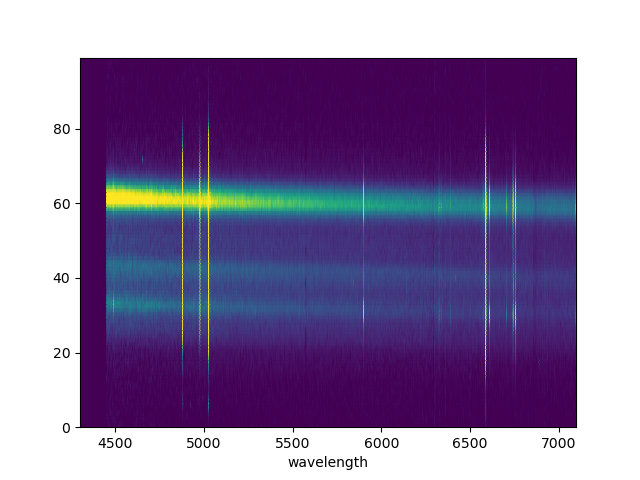

In [5]:
wavelengths = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelengths, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

In [6]:
z = 0.00442
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/PSF/Real_seeing_Mrk1263.txt")
sigma = seeing[0] / 2.35

In [7]:
l_OIII

5029.13094

Text(0.5, 1.0, 'H$\\alpha$')

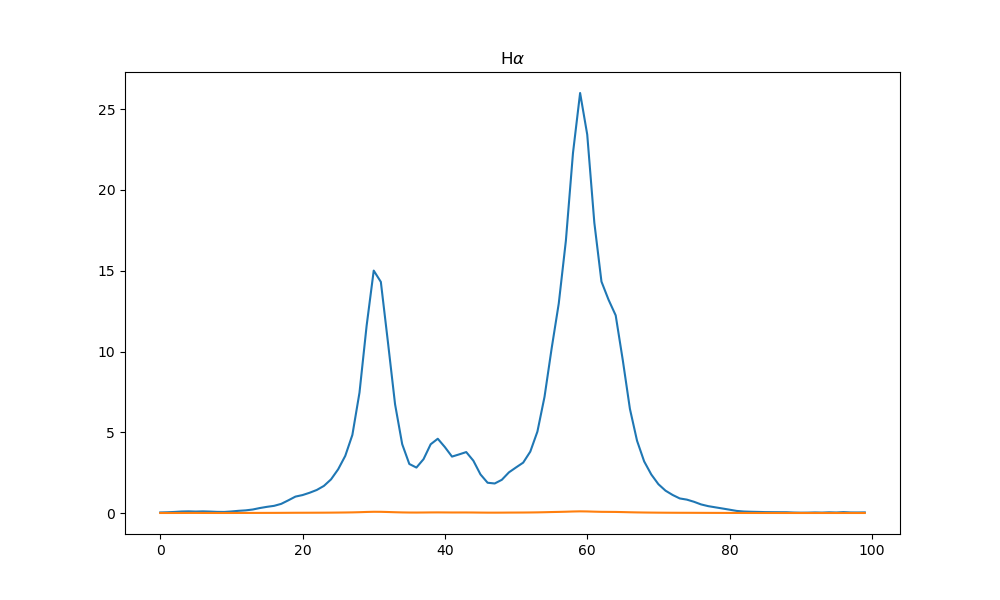

In [8]:
#Ogni punto del flusso è il risultato della somma di 20 lunghezze d'onda 
mask_HA = (wavelengths > l_HA-8)*(wavelengths < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [9]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

#Define the function for the aic
#Per l'AIC test usiamo il chi quadro perchè il numero di conteggi è elevato (S/N grande) 
#quindi Poisson --> Gauss
#def chi_quad(x, y, y_err, params):
#    return np.sum((((y - model_convolved(x, *params)) / y_err)**2))
    
def AIC(x, y, chi, params): #k=number of model parameter, N=number of data points
    return chi + 2*len(params) +((2*len(params)*(len(params)+1))/(len(y)-len(params)-1))

def BIC(x, y, chi, params):
        return chi + len(params)*np.log(len(y))
    
def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def save_params(params_curve, covariance, radial_profile, radial_profile_error, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, chi2

In [10]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params) 
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),  # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params1 = result.x

print("Optimize parameters with differential_evolution:", best_params1)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 2774.017658198147
differential_evolution step 2: f(x)= 2691.8011135052616
differential_evolution step 3: f(x)= 2691.8011135052616
differential_evolution step 4: f(x)= 2691.8011135052616
differential_evolution step 5: f(x)= 2687.025390916695
differential_evolution step 6: f(x)= 2633.0905360425977
differential_evolution step 7: f(x)= 2633.0905360425977
differential_evolution step 8: f(x)= 2576.432600270699
differential_evolution step 9: f(x)= 2576.432600270699
differential_evolution step 10: f(x)= 2576.432600270699
differential_evolution step 11: f(x)= 2556.028602824814
differential_evolution step 12: f(x)= 2556.028602824814
differential_evolution step 13: f(x)= 2542.9788725509743
differential_evolution step 14: f(x)= 2542.9788725509743
differential_evolution step 15: f(x)= 2538.1374356708384
differential_evolution step 16: f(x)= 2533.0058026607867
differential_evolution step 17: f(x)= 2533.0058026607867
differential_evolution step 18: f(x)= 2528.8157

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9892\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9892\111436280.py:9: RuntimeWarning: overflow encountered in multiply
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9892\2931390679.py:7: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=4.1220, r_e=19.0451, n=0.1240, x_0=46.5620
[0.45556175 3.26963903 0.0568854  0.82934677]
3432.77856141795
3441.199614049529 0.0 3451.1992421619025 4


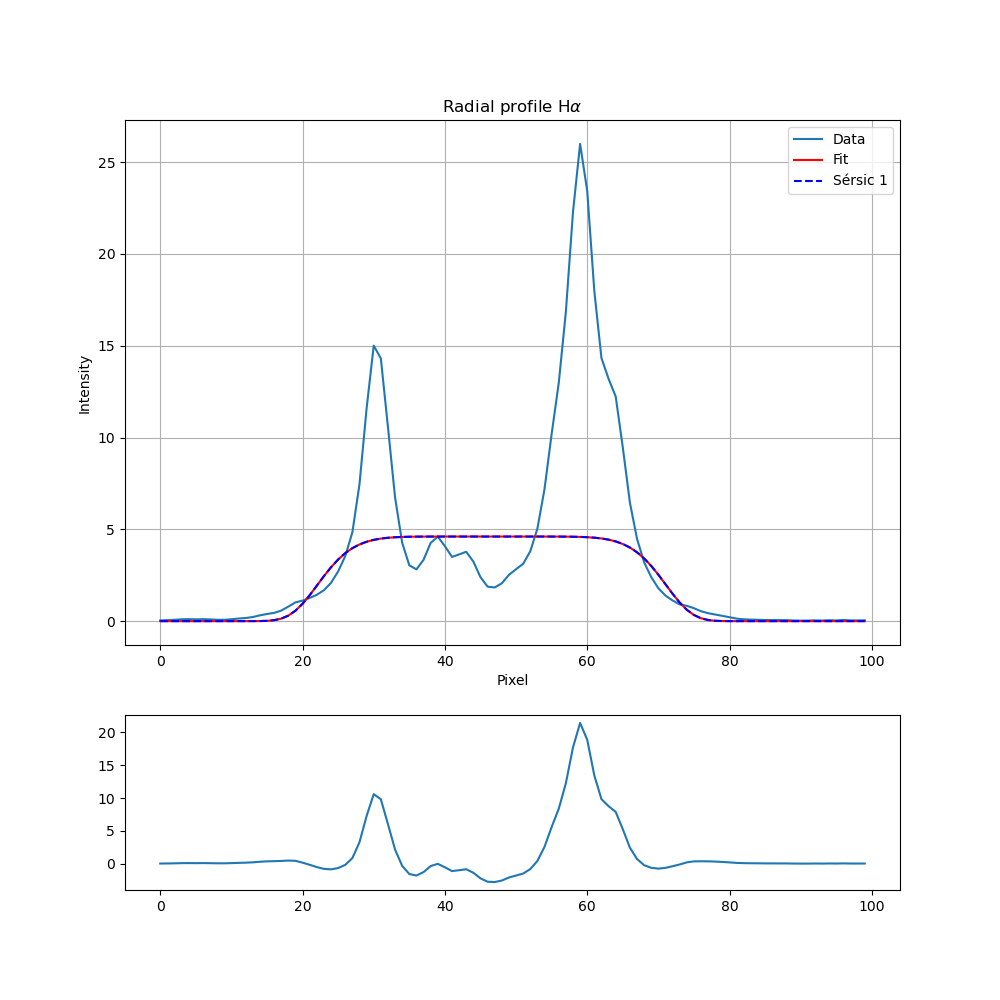

In [11]:
aic = np.zeros(7)
bic = np.zeros(7)
chi_quadr = np.zeros(7)
chi_quadro = np.zeros(7)
red_chi = np.zeros(7)

params_curve_1, covariance_1 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params1,
                                         sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[0], red_chi[0] = save_params(params_curve_1, covariance_1, radial_profile_HA, radial_profile_error_HA, x_axes, 1, line_name="One", 
                                           output_prefix="fit")

aic[0] = AIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
bic[0] = BIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
print(aic[0], chi_quadro[0], bic[0], len(params_curve_1))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_1)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_1), 'b--', label='Sérsic 1')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_1', bbox_inches='tight')

In [12]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =  [
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (35, 40),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params2 = result.x

print("Optimize parameters with differential_evolution:", best_params2)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 2703.9542922585706
differential_evolution step 2: f(x)= 2687.139913224367
differential_evolution step 3: f(x)= 2687.139913224367
differential_evolution step 4: f(x)= 2575.95463219714
differential_evolution step 5: f(x)= 2443.640012982235
differential_evolution step 6: f(x)= 2443.640012982235
differential_evolution step 7: f(x)= 2443.640012982235
differential_evolution step 8: f(x)= 2443.640012982235
differential_evolution step 9: f(x)= 2443.640012982235
differential_evolution step 10: f(x)= 2443.640012982235
differential_evolution step 11: f(x)= 2443.640012982235
differential_evolution step 12: f(x)= 2333.8205564156283
differential_evolution step 13: f(x)= 2333.8205564156283
differential_evolution step 14: f(x)= 2333.8205564156283
differential_evolution step 15: f(x)= 2333.8205564156283
differential_evolution step 16: f(x)= 2333.8205564156283
differential_evolution step 17: f(x)= 2198.771797730866
differential_evolution step 18: f(x)= 2198.771797730

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9892\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9892\1678542767.py:8: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=9.9200, r_e=1.3394, n=0.2525, x_0=30.2798
Sérsic 2: I_e=3.7442, r_e=18.1633, n=0.1587, x_0=46.8149
[18.95195801  0.50067721  1.77906844  0.40461135  0.36867604  1.81095006
  0.06261277  0.91940128]
2953.1486596078435
2970.731077190261 2953.1486596078435 2989.990021095748 8


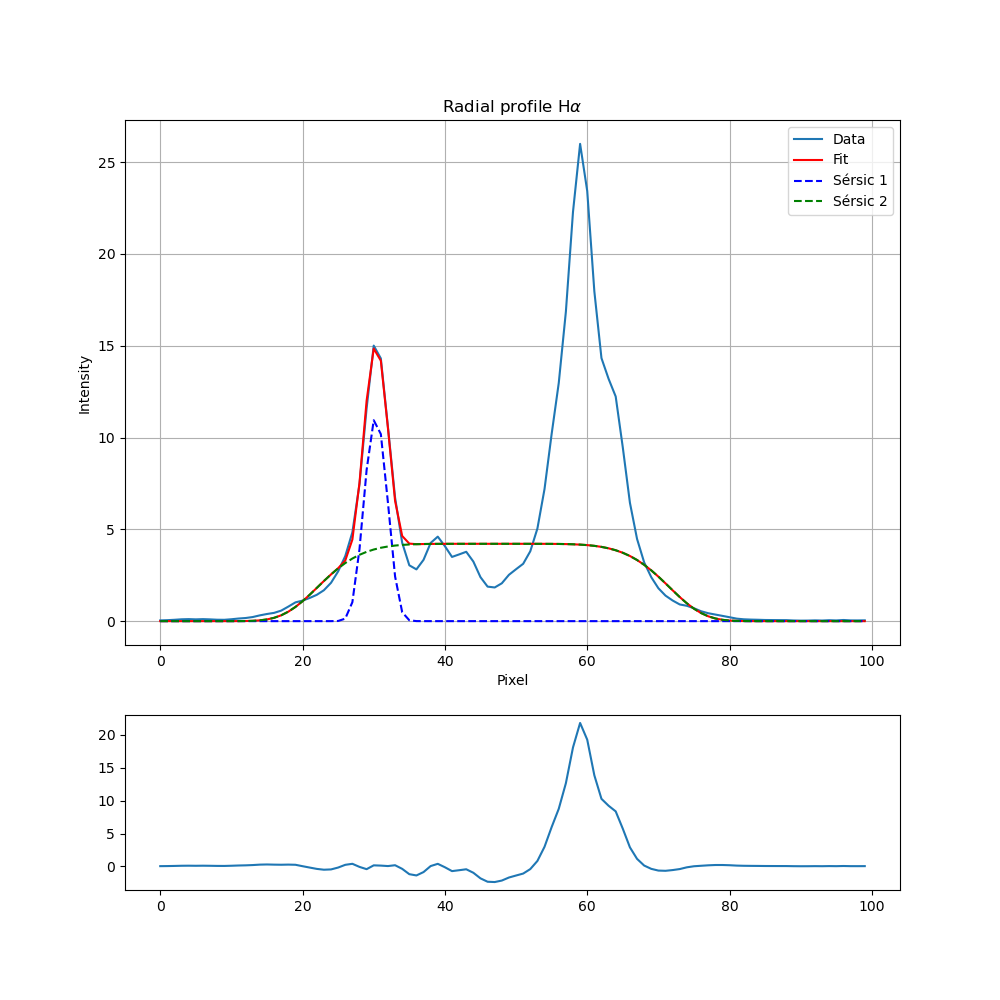

In [13]:
# Plots:
params_curve_2, covariance_2 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params2, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[1], red_chi[1] = save_params(params_curve_2, covariance_2, radial_profile_HA, radial_profile_error_HA,
    x_axes, 2, line_name="Two", output_prefix="fit")

aic[1] = AIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
bic[1] = BIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
print(aic[1], chi_quadr[1], bic[1], len(params_curve_2))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_2)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[4:8]), 'g--', label='Sérsic 2')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_2', bbox_inches='tight')

In [16]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (37, 40),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (42, 44),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params3 = result.x

print("Optimize parameters with differential_evolution:", best_params3)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 7012.481807881839
differential_evolution step 2: f(x)= 6922.085305584493
differential_evolution step 3: f(x)= 4637.264412036875
differential_evolution step 4: f(x)= 2623.8669328904098
differential_evolution step 5: f(x)= 2623.8669328904098
differential_evolution step 6: f(x)= 2623.8669328904098
differential_evolution step 7: f(x)= 2623.8669328904098
differential_evolution step 8: f(x)= 2623.8669328904098
differential_evolution step 9: f(x)= 2623.8669328904098
differential_evolution step 10: f(x)= 2623.8669328904098
differential_evolution step 11: f(x)= 2623.8669328904098
differential_evolution step 12: f(x)= 2623.8669328904098
differential_evolution step 13: f(x)= 2600.9008985118844
differential_evolution step 14: f(x)= 2600.9008985118844
differential_evolution step 15: f(x)= 2554.876904039142
differential_evolution step 16: f(x)= 2554.876904039142
differential_evolution step 17: f(x)= 2554.876904039142
differential_evolution step 18: f(x)= 2554.876

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9892\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9892\1344549781.py:9: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=4.8959, r_e=1.7529, n=0.0447, x_0=30.3512
Sérsic 2: I_e=1.2867, r_e=23.0014, n=0.1288, x_0=46.2649
Sérsic 3: I_e=0.1744, r_e=22.8221, n=0.0258, x_0=46.8359
[1.46851749e+03 2.37681829e+01 6.90662996e+00 4.09191831e-01
 1.77400911e+00 1.78858282e+01 2.23603757e-01 1.68824115e+00
 4.85308813e+00 1.99391030e+00 1.23165639e-01 9.41203332e-01]
2943.9712702135153
2971.557477110067 2943.9712702135153 2999.2333124453726 12


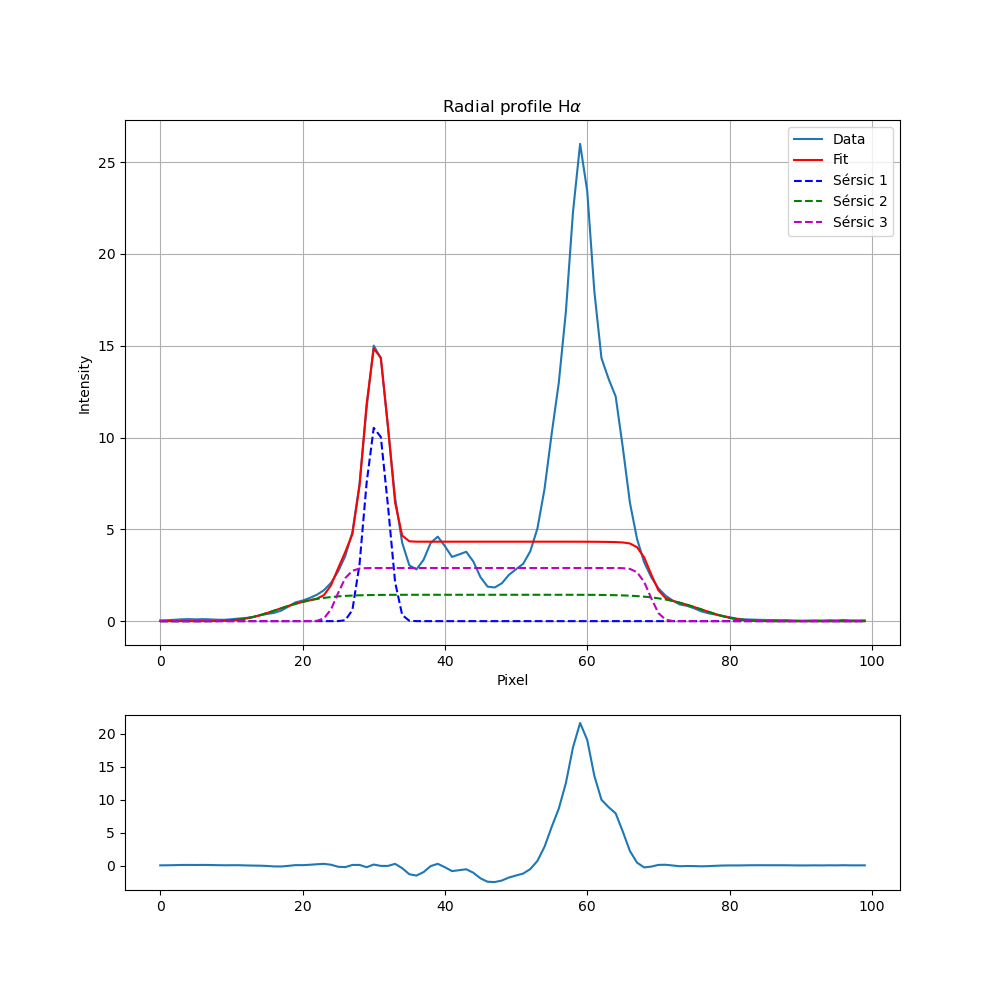

In [17]:
# Plots:
params_curve_3, covariance_3 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params3, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[2], red_chi[2] = save_params(params_curve_3, covariance_3, radial_profile_HA, radial_profile_error_HA,x_axes, 3,  
                                       line_name="Three", output_prefix="fit")

aic[2] = AIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
bic[2] = BIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
print(aic[2], chi_quadr[2], bic[2], len(params_curve_3))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_3)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[8:12]), 'm--', label='Sérsic 3')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_3', bbox_inches='tight')

In [18]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (37, 40),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (41, 44),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 63),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params4 = result.x

print("Optimize parameters with differential_evolution:", best_params4)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 28096.50903648374
differential_evolution step 2: f(x)= 11069.569114143145
differential_evolution step 3: f(x)= 637.0450073096089
differential_evolution step 4: f(x)= 637.0450073096089
differential_evolution step 5: f(x)= 637.0450073096089
differential_evolution step 6: f(x)= 637.0450073096089
differential_evolution step 7: f(x)= 637.0450073096089
differential_evolution step 8: f(x)= 637.0450073096089
differential_evolution step 9: f(x)= 637.0450073096089
differential_evolution step 10: f(x)= 637.0450073096089
differential_evolution step 11: f(x)= 637.0450073096089
differential_evolution step 12: f(x)= 637.0450073096089
differential_evolution step 13: f(x)= 637.0450073096089
differential_evolution step 14: f(x)= 637.0450073096089
differential_evolution step 15: f(x)= 637.0450073096089
differential_evolution step 16: f(x)= 621.1027100779842
differential_evolution step 17: f(x)= 580.1343917466967
differential_evolution step 18: f(x)= 580.1343917466967


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9892\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9892\3964332783.py:10: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=1.1459, r_e=8.9258, n=1.8572, x_0=30.3304
Sérsic 2: I_e=0.3132, r_e=1.5131, n=0.0280, x_0=38.8244
Sérsic 3: I_e=1.1084, r_e=2.1094, n=0.7909, x_0=42.8039
Sérsic 4: I_e=5.5687, r_e=6.4903, n=1.0055, x_0=59.4559
[1.67169707e-01 7.84190360e-01 1.25546680e-01 6.48702327e-02
 5.31162766e+02 1.08527125e+01 9.69705641e+00 3.59229050e-01
 1.06854679e+00 9.47713904e-01 7.67744672e-01 4.82648222e-01
 2.74061548e-01 1.69787264e-01 3.94875139e-02 6.00822745e-02]
85.9788452360406
124.53306210351047 85.9788452360406 159.66156821185007 16


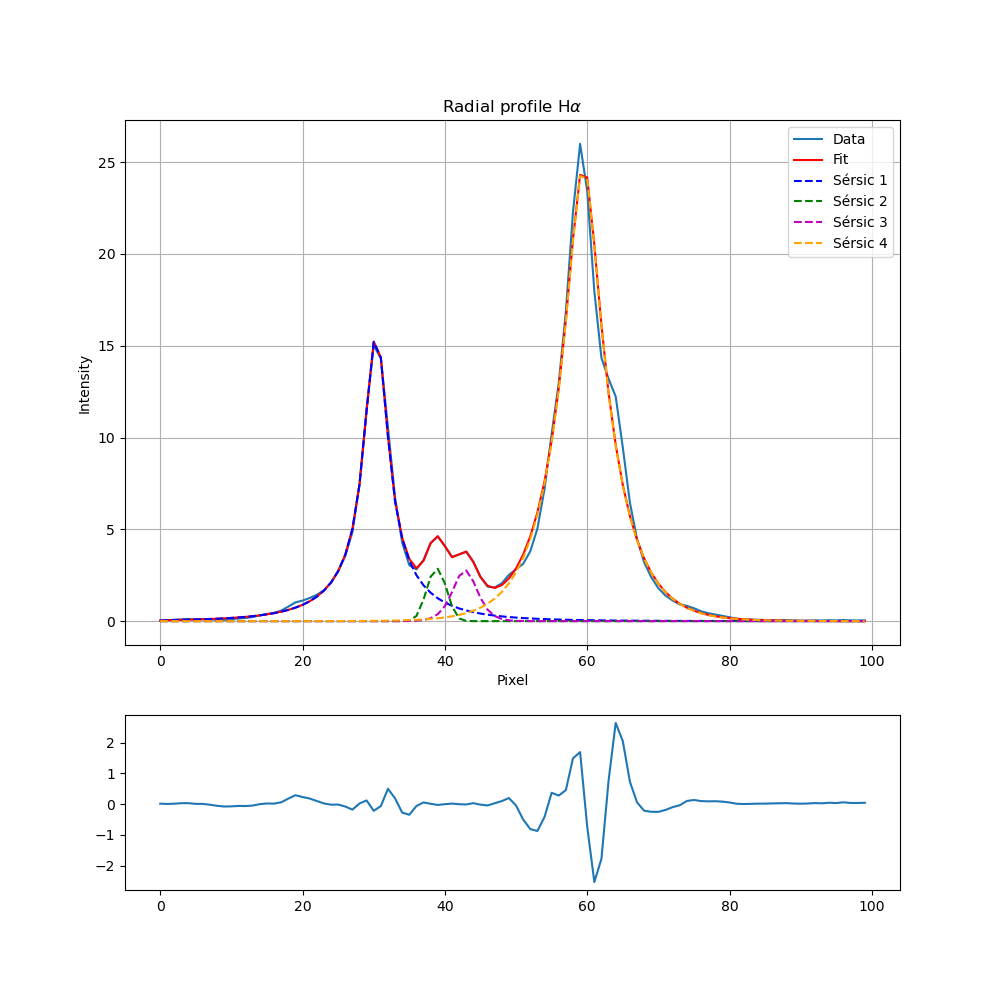

In [19]:
# Plots:
params_curve_4, covariance_4 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params4, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[3], red_chi[3] = save_params(params_curve_4, covariance_4, radial_profile_HA, radial_profile_error_HA, x_axes, 4, line_name="Four", output_prefix="fit")

aic[3] = AIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
bic[3] = BIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
print(aic[3], chi_quadr[3], bic[3], len(params_curve_4))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_4)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_4', bbox_inches='tight')

In [24]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (38, 41),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (42, 45),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 63),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (60, 65)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params5 = result.x

print("Optimize parameters with differential_evolution:", best_params5)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 15206.001915506973
differential_evolution step 2: f(x)= 15206.001915506973
differential_evolution step 3: f(x)= 3419.1138050188374
differential_evolution step 4: f(x)= 3419.1138050188374
differential_evolution step 5: f(x)= 3419.1138050188374
differential_evolution step 6: f(x)= 3419.1138050188374
differential_evolution step 7: f(x)= 2192.095992504386
differential_evolution step 8: f(x)= 1773.1926942924365
differential_evolution step 9: f(x)= 1773.1926942924365
differential_evolution step 10: f(x)= 1773.1926942924365
differential_evolution step 11: f(x)= 1773.1926942924365
differential_evolution step 12: f(x)= 913.53468726249
differential_evolution step 13: f(x)= 913.53468726249
differential_evolution step 14: f(x)= 913.53468726249
differential_evolution step 15: f(x)= 913.53468726249
differential_evolution step 16: f(x)= 913.53468726249
differential_evolution step 17: f(x)= 913.53468726249
differential_evolution step 18: f(x)= 913.53468726249
diffe

Optimize parameters with curve fit:
Sérsic 1: I_e=1.2247, r_e=8.0326, n=1.8140, x_0=30.2972
Sérsic 2: I_e=0.1363, r_e=2.4802, n=3.6522, x_0=38.9285
Sérsic 3: I_e=0.0619, r_e=23.9476, n=2.7386, x_0=42.8349
Sérsic 4: I_e=0.7375, r_e=11.1462, n=2.0816, x_0=58.7959
Sérsic 5: I_e=5.7191, r_e=5.1261, n=0.5477, x_0=60.2481
[3.18681635e-01 1.53424300e+00 2.01611487e-01 6.22593233e-02
 3.10531795e+00 3.36792261e+01 2.37935263e+01 1.53817431e-01
 1.64519100e-01 5.38521416e+01 1.90482237e+00 2.49685254e-01
 8.58387885e-01 5.89279422e+00 1.03140966e+00 1.78575848e-02
 7.84593024e-01 2.77230153e-01 5.30492039e-02 2.67409668e-01]
58.03950819075307
108.67241958315813 58.03950819075307 150.1429119105149 20


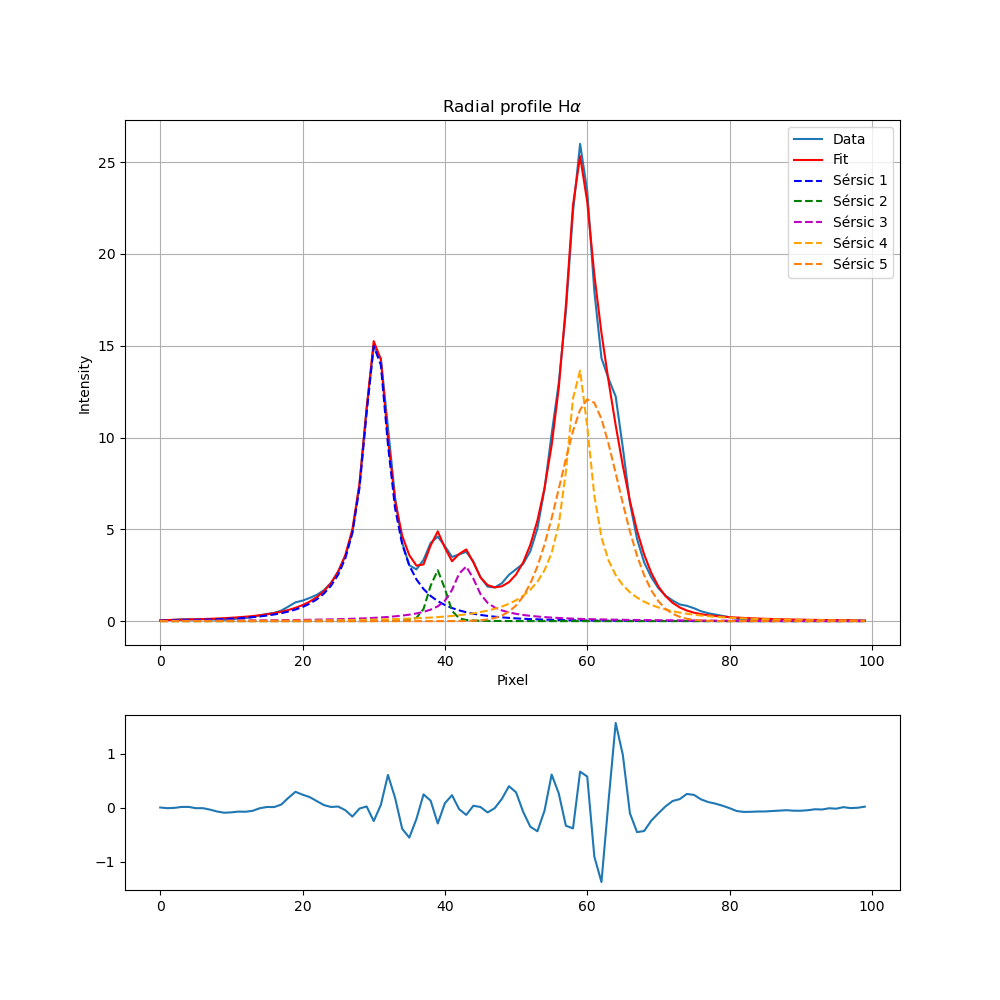

In [25]:
# Plots:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_5, covariance_5 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params5, 
                                         sigma = radial_profile_error_HA, maxfev=10000, bounds = bounds_list)

print("Optimize parameters with curve fit:")

chi_quadr[4], red_chi[4] = save_params(params_curve_5, covariance_5, radial_profile_HA, radial_profile_error_HA, x_axes, 5, line_name="Five", output_prefix="fit")

aic[4] = AIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
bic[4] = BIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
print(aic[4], chi_quadr[4], bic[4], len(params_curve_5))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_5)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[16:20]),  linestyle='--', label='Sérsic 5')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_5', bbox_inches='tight')

In [26]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (37, 40),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (41, 44),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 63),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (60, 65),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params6 = result.x

print("Optimize parameters with differential_evolution:", best_params6)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 46967.419101523505
differential_evolution step 2: f(x)= 21386.809962846895
differential_evolution step 3: f(x)= 21161.006665431534
differential_evolution step 4: f(x)= 21161.006665431534
differential_evolution step 5: f(x)= 8305.520409585492
differential_evolution step 6: f(x)= 8305.520409585492
differential_evolution step 7: f(x)= 8305.520409585492
differential_evolution step 8: f(x)= 8305.520409585492
differential_evolution step 9: f(x)= 5182.504267622874
differential_evolution step 10: f(x)= 3282.498892212021
differential_evolution step 11: f(x)= 3282.498892212021
differential_evolution step 12: f(x)= 3282.498892212021
differential_evolution step 13: f(x)= 3282.498892212021
differential_evolution step 14: f(x)= 3282.498892212021
differential_evolution step 15: f(x)= 1639.8697032687867
differential_evolution step 16: f(x)= 1639.8697032687867
differential_evolution step 17: f(x)= 1639.8697032687867
differential_evolution step 18: f(x)= 1639.8697032

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9892\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9892\1593450380.py:12: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=1.1223, r_e=8.9753, n=1.8730, x_0=30.3222
Sérsic 2: I_e=0.5777, r_e=1.5301, n=0.0328, x_0=38.9053
Sérsic 3: I_e=0.5630, r_e=2.9766, n=1.2805, x_0=42.8498
Sérsic 4: I_e=3.5588, r_e=7.2005, n=1.3463, x_0=59.0513
Sérsic 5: I_e=0.7388, r_e=3.6402, n=1.6459, x_0=64.0246
Sérsic 6: I_e=0.0591, r_e=0.0545, n=4.7246, x_0=55.5034
[8.25908645e-02 3.96340306e-01 6.32957446e-02 3.25292625e-02
 2.61799435e+02 7.07098456e+00 4.12183357e+00 1.57270245e-01
 5.46385139e-01 1.79797586e+00 7.53378346e-01 2.07103565e-01
 2.59120411e-01 3.08916795e-01 5.39857857e-02 5.09554235e-02
 5.14229343e-01 1.65602327e+00 5.71073296e-01 1.11566847e-01
 5.51458832e+03 2.32163866e+03 3.51928859e+05 6.01456002e+00]
20.14845573784789
84.14845573784788 20.14845573784789 130.6725402015621 24


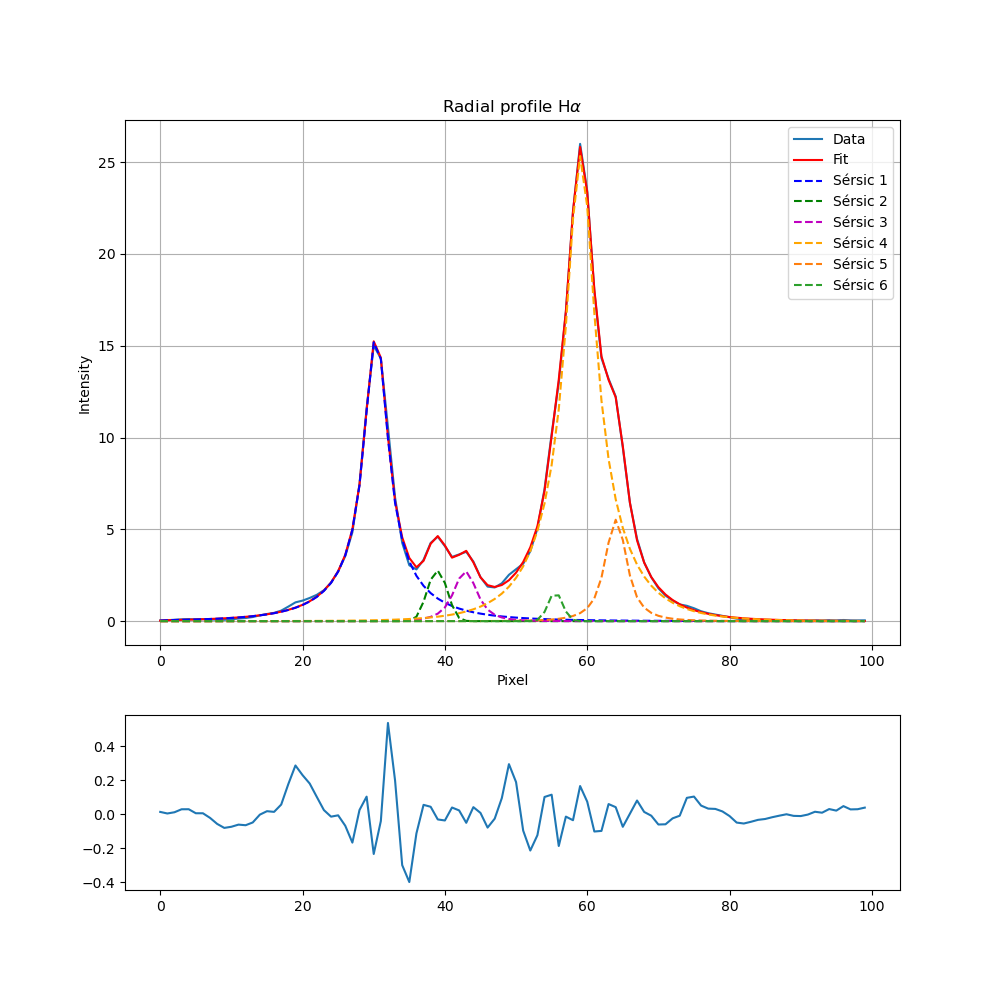

In [27]:
# Plots:
params_curve_6, covariance_6 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params6, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[5], red_chi[5] = save_params(params_curve_6, covariance_6, radial_profile_HA, radial_profile_error_HA, x_axes, 6,
                                       line_name="Six", output_prefix="fit")

aic[5] = AIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
bic[5] = BIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
print(aic[5], chi_quadr[5], bic[5], len(best_params6))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_6)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[20:24]),  linestyle='--', label='Sérsic 6')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_6', bbox_inches='tight')

In [28]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24]) +
        sersic_1d(x_hr, *params[24:28])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (37, 40),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (41, 44),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 63),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (60, 65),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params7 = result.x

print("Optimize parameters with differential_evolution:", best_params7)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 235857.53926423242
differential_evolution step 2: f(x)= 65907.48055095256
differential_evolution step 3: f(x)= 65907.48055095256
differential_evolution step 4: f(x)= 65907.48055095256
differential_evolution step 5: f(x)= 65907.48055095256
differential_evolution step 6: f(x)= 60817.506693347015
differential_evolution step 7: f(x)= 31582.37274068046
differential_evolution step 8: f(x)= 31582.37274068046
differential_evolution step 9: f(x)= 31582.37274068046
differential_evolution step 10: f(x)= 31582.37274068046
differential_evolution step 11: f(x)= 10684.916773851673
differential_evolution step 12: f(x)= 10684.916773851673
differential_evolution step 13: f(x)= 6165.92624747007
differential_evolution step 14: f(x)= 4298.476402681938
differential_evolution step 15: f(x)= 4298.476402681938
differential_evolution step 16: f(x)= 4298.476402681938
differential_evolution step 17: f(x)= 4298.476402681938
differential_evolution step 18: f(x)= 4298.47640268193

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9892\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9892\2802529658.py:13: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9892\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with curve fit:
Sérsic 1: I_e=0.9539, r_e=9.8153, n=2.0088, x_0=30.3189
Sérsic 2: I_e=1.1419, r_e=1.3349, n=1.0112, x_0=38.9532
Sérsic 3: I_e=0.2718, r_e=4.9212, n=1.8091, x_0=42.8968
Sérsic 4: I_e=3.9028, r_e=6.7112, n=1.2787, x_0=59.0467
Sérsic 5: I_e=0.5630, r_e=4.7005, n=1.8055, x_0=64.0453
Sérsic 6: I_e=0.0651, r_e=0.6428, n=4.0758, x_0=55.4291
Sérsic 7: I_e=0.0143, r_e=42.2131, n=0.0905, x_0=65.2226
[1.07877519e-01 7.13723151e-01 9.42008502e-02 3.70874697e-02
 1.90004842e+00 1.13298441e+00 1.44130977e+00 1.43089585e-01
 6.95367150e-01 1.00396305e+01 1.88686827e+00 1.81199377e-01
 7.11077121e-01 1.32614299e+00 1.31764439e-01 6.24431253e-02
 9.58667195e-01 7.21595618e+00 1.27344200e+00 1.56395181e-01
 5.30270888e+01 2.90547997e+02 6.31086261e+03 4.03830933e-01
 7.36684579e-02 3.84983458e+02 9.72766460e-01 3.29228885e+02]
23.776915000464626
102.65015443708435 23.776915000464626 152.7216802081312 28


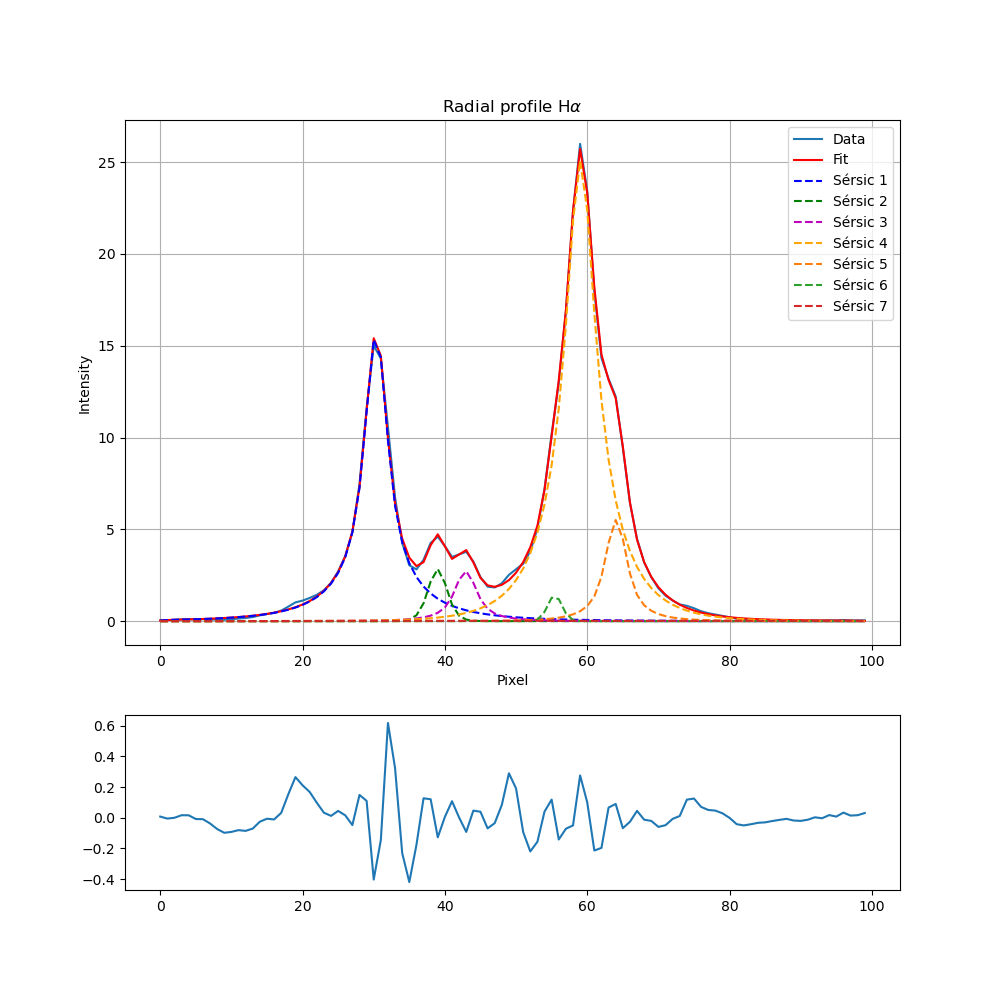

In [29]:
# Plots:
params_curve_7, covariance_7 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params7, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[6], red_chi[6] = save_params(params_curve_7, covariance_7, radial_profile_HA, radial_profile_error_HA, x_axes, 7, 
                                       line_name="Seven", output_prefix="fit")

aic[6] = AIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
bic[6] = BIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
print(aic[6], chi_quadr[6], bic[6], len(best_params7))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_7)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[20:24]),  linestyle='--', label='Sérsic 6')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[24:28]),  linestyle='--', label='Sérsic 7')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_7', bbox_inches='tight')

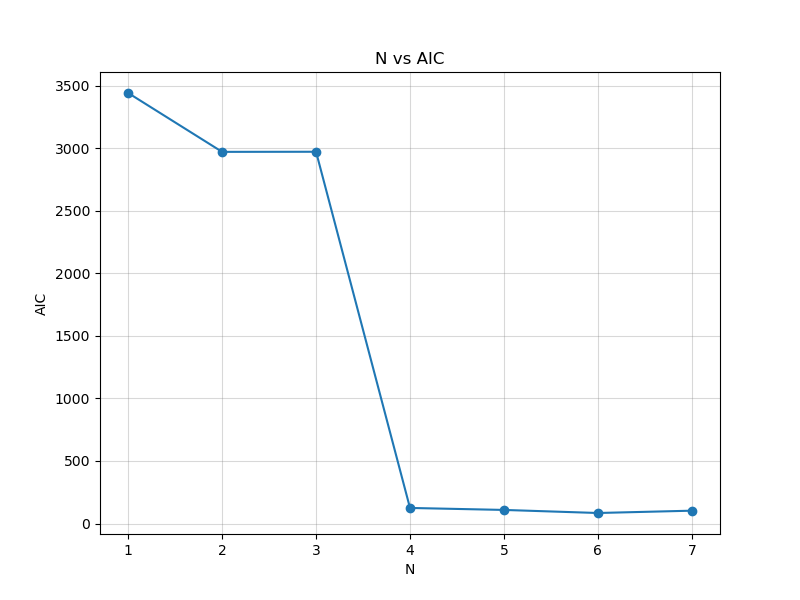

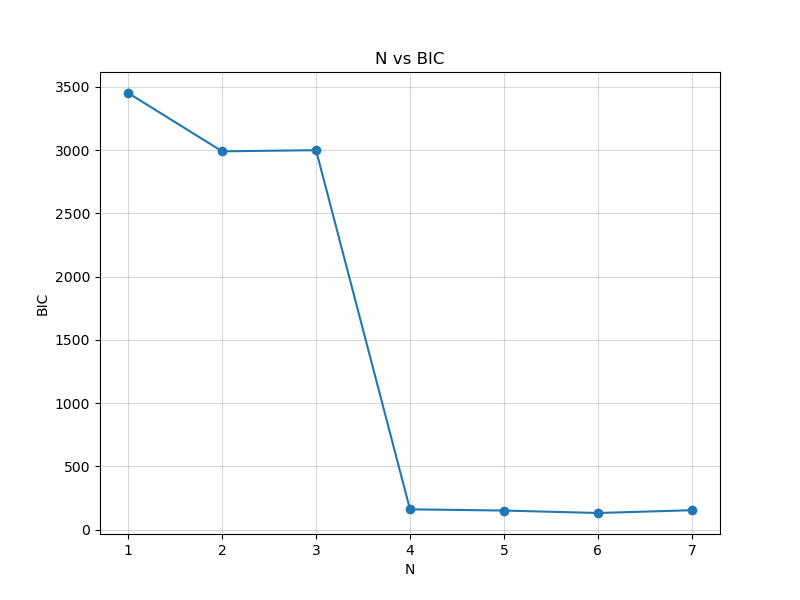

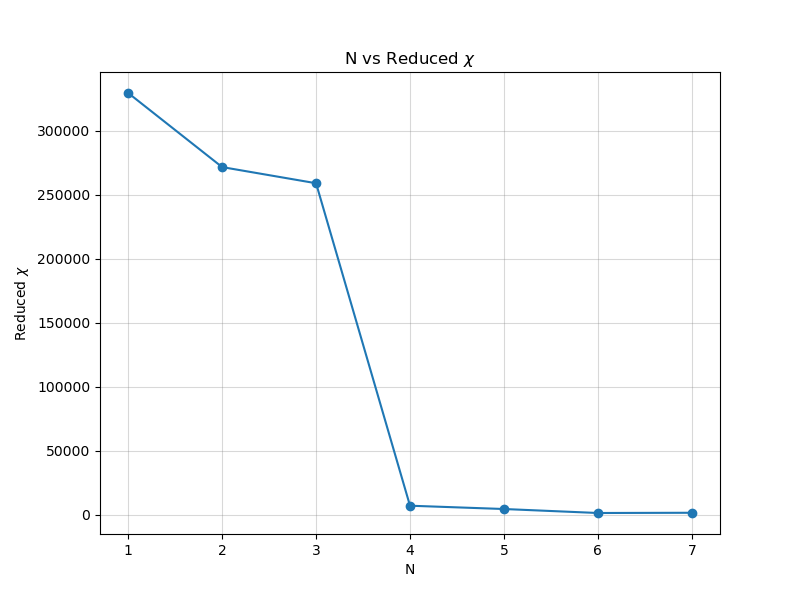

In [30]:
#Plot AIC vs N 
n = [1, 2, 3, 4, 5, 6, 7]

fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('AIC')
ax1.set_title('N vs AIC')
ax1.plot(n, aic, marker = 'o')
plt.savefig('AIC_vs_N', bbox_inches='tight')
np.savetxt('AIC', aic)
np.savetxt('Reduced_chi', red_chi)

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('BIC')
ax2.set_title('N vs BIC')
ax2.plot(n, bic, marker = 'o')
plt.savefig('BIC_vs_N', bbox_inches='tight')
np.savetxt('BIC', aic)

fig3 = plt.figure(figsize=(8,6))
ax3 = fig3.gca()
ax3.grid(alpha=0.3, c = 'grey')
ax3.set_xlabel('N')
ax3.set_ylabel('Reduced $\chi$')
ax3.set_title('N vs Reduced $\chi$')
ax3.plot(n, red_chi, marker = 'o')
plt.savefig('Reduced_chi_vs_N', bbox_inches='tight')

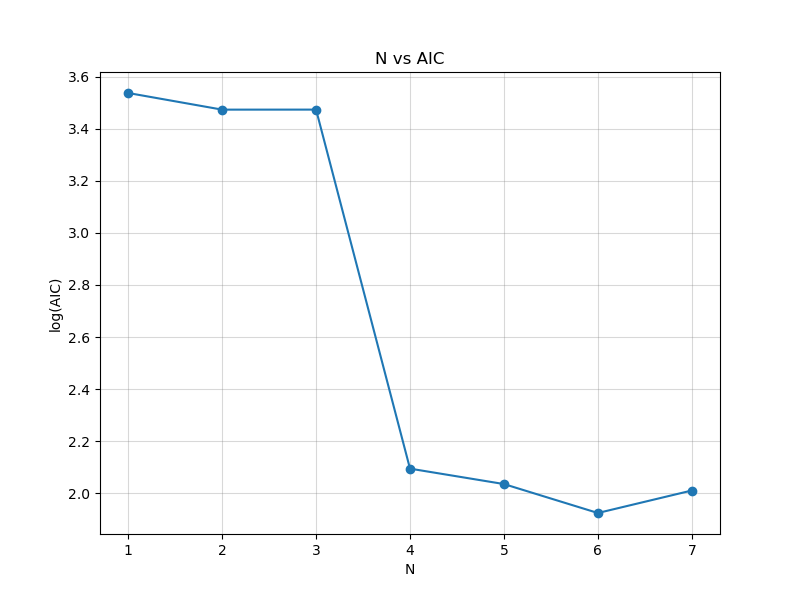

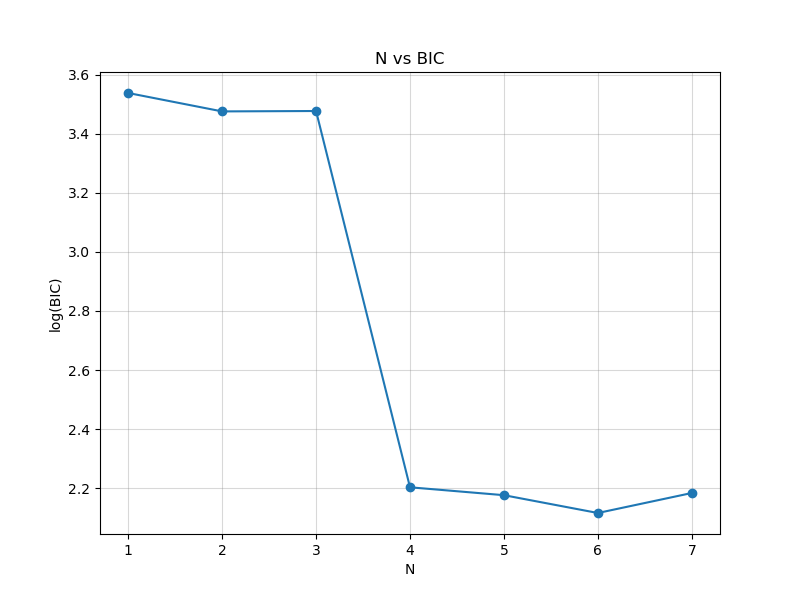

In [31]:
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('log(AIC)')
ax1.set_title('N vs AIC')
ax1.plot(n, np.log10(aic), marker = 'o')
plt.savefig('AIC_vs_N_log', bbox_inches='tight')

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('log(BIC)')
ax2.set_title('N vs BIC')
ax2.plot(n, np.log10(bic), marker = 'o')
plt.savefig('BIC_vs_N_log', bbox_inches='tight')